## Case Study: Retail Sales Performance Analysis (Seaborn EDA)

    Business Problem

    A retail company wants to understand:
        Which product categories generate the highest sales?
        How does discount impact profit?
        Which regions perform poorly?
        Are there seasonal trends in sales?

   Goal: Use data visualization (Seaborn) to generate actionable business insights for decision-making.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

np.random.seed(42)

n = 1000

df = pd.DataFrame({
    "order_id": range(1, n+1),
    "region": np.random.choice(["North", "South", "East", "West"], n),
    "category": np.random.choice(["Furniture", "Technology", "Office Supplies"], n),
    "sales": np.random.randint(100, 20000, n),
    "discount": np.random.uniform(0, 0.5, n),
    "profit": np.random.randint(-5000, 8000, n),
    "order_date": pd.date_range(start="2023-01-01", periods=n, freq="D")
})

df.head()

,order_id,region,category,sales,discount,profit,order_date
0,1,East,Technology,9087,0.066740,2032,2023-01-01
1,2,West,Office Supplies,12980,0.040301,-4008,2023-01-02
2,3,North,Furniture,5333,0.363970,3112,2023-01-03
3,4,East,Furniture,9616,0.248231,287,2023-01-04
4,5,East,Furniture,14659,0.218425,5578,2023-01-05


In [3]:
df.dtypes

order_id               int64
region                object
category              object
sales                  int32
discount             float64
profit                 int32
order_date    datetime64[ns]
dtype: object

## Data Type Conversion

In [4]:
df["region"] = df["region"].astype("category")
df["category"] = df["category"].astype("category")
df["order_date"] = pd.to_datetime(df["order_date"])

### 1.Which Category has highest sales?
    insights:-
        Identifies top-revenue generating category.

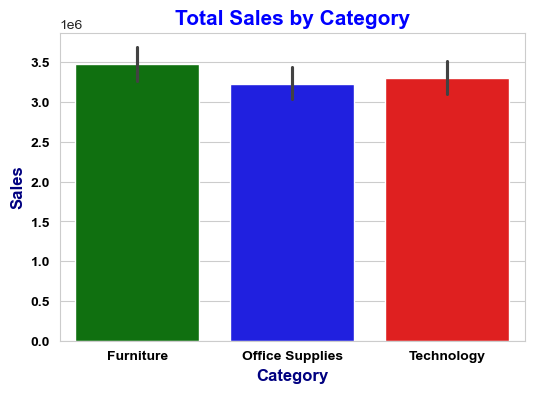

In [47]:
plt.figure(figsize=(6,4))

sns.barplot(x="category", y="sales", hue='category',data=df, estimator=np.sum,palette=['green', 'blue', 'red'])
plt.title("Total Sales by Category",fontsize=15,fontweight='bold',color='Blue')

plt.xticks(fontsize=10,color='black',fontweight='bold')
plt.yticks(fontsize=10,color='black',fontweight='bold')

plt.ylabel('Sales',fontsize=12,fontweight='bold',color='navy')
plt.xlabel('Category',fontsize=12,fontweight='bold',color='navy')

plt.show()

### Which Region is underperforming?
    insights
            Regions with negative median profit = business risk zones

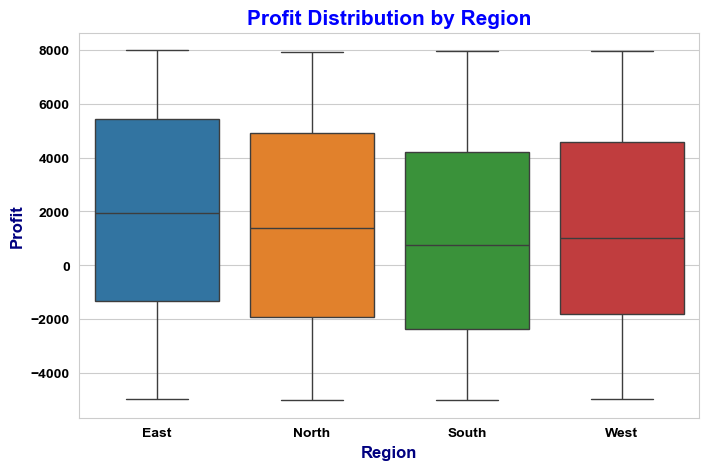

In [44]:
plt.figure(figsize=(8,5))
sns.boxplot(x="region",
            y="profit",
            data=df,
           hue='region'
           
)
plt.title("Profit Distribution by Region",fontsize=15,fontweight='bold',color='blue')

plt.xticks(fontsize=10,color='black',fontweight='bold')
plt.yticks(fontsize=10,color='black',fontweight='bold')

plt.xlabel('Region',fontsize=12,fontweight='bold',color='navy')
plt.ylabel('Profit',fontsize=12,fontweight='bold',color='navy')
plt.show()

### Does discount affect profit?
Insight:
    Higher discount often reduces profit → pricing strategy issue

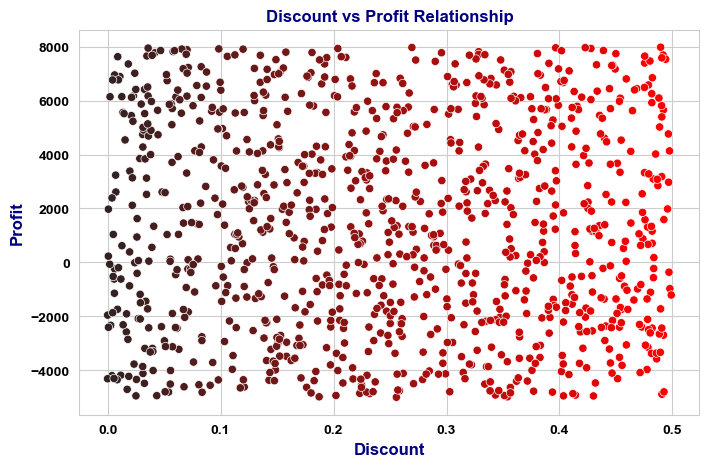

In [46]:

plt.figure(figsize=(8,5))
sns.scatterplot(x="discount", 
                y="profit",
                hue='discount',
                data=df,
                palette='dark:r',
                legend=False
               )
plt.title("Discount vs Profit Relationship",fontsize=12,fontweight='bold',color='navy')

plt.xticks(fontsize=10,color='black',fontweight='bold')
plt.yticks(fontsize=10,color='black',fontweight='bold')


plt.xlabel('Discount',fontsize=12,fontweight='bold',color='navy')
plt.ylabel('Profit',fontsize=12,fontweight='bold',color='navy')

plt.show()



### Monthly Sales Trend
    Insight:
        Identifies peak and low demand seasons
        

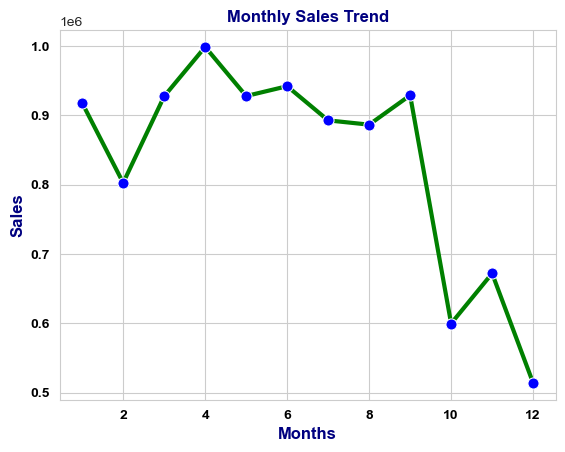

In [45]:

df["month"] = df["order_date"].dt.month

monthly_sales = df.groupby("month")["sales"].sum().reset_index()

sns.lineplot(x="month",
             y="sales",
             data=monthly_sales,
            color='green',
             linewidth=3,
             marker='o',
             mfc='blue',
            ms=8,
             
            )
plt.title("Monthly Sales Trend",fontsize=12,fontweight='bold',color='navy')

plt.xticks(fontsize=10,color='black',fontweight='bold')
plt.yticks(fontsize=10,color='black',fontweight='bold')

plt.xlabel('Months',fontsize=12,fontweight='bold',color='navy')
plt.ylabel('Sales',fontsize=12,fontweight='bold',color='navy')
plt.show()



### Which region has the widest varation in sale?

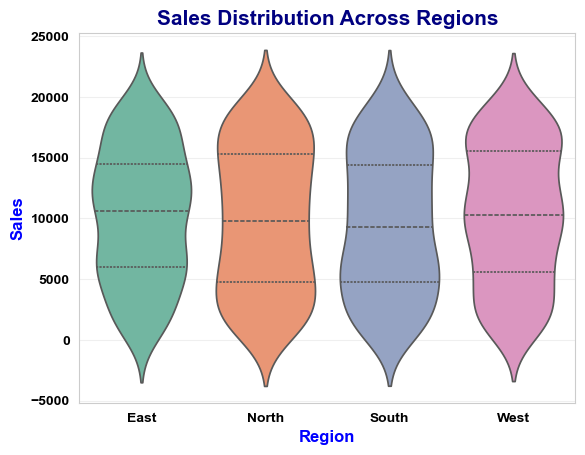

In [62]:
sns.violinplot(
    data=df,
    x='region',
    y='sales',
    hue='region',
    palette='Set2',
    inner='quart',
    legend=False
)

plt.title(
    "Sales Distribution Across Regions",
    fontsize=15,
    fontweight='bold',
    color='navy'
)

plt.xlabel("Region", fontsize=12, fontweight='bold',color='blue')
plt.ylabel("Sales",fontsize=12, fontweight='bold',color='blue')
plt.xticks(fontsize=10,color='black',fontweight='bold')
plt.yticks(fontsize=10,color='black',fontweight='bold')

plt.grid(axis='y', alpha=0.3)

### Which product category recieves the highest number of orders in each region?

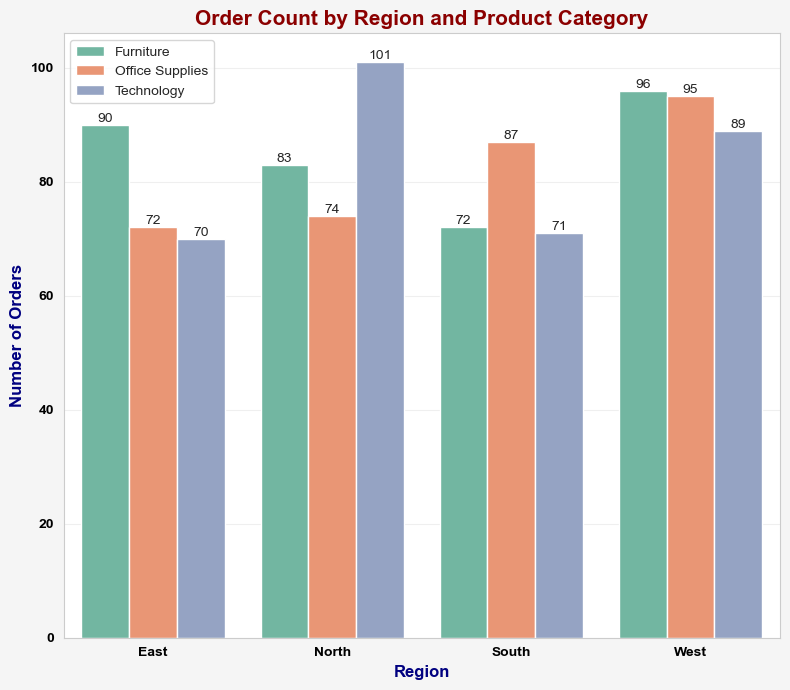

In [63]:

plt.figure(figsize=(8,7), facecolor='whitesmoke')

ax = sns.countplot(
    data=df,
    x='region',
    hue='category',
    palette='Set2'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Order Count by Region and Product Category",
    fontsize=15,
    fontweight='bold',
    color='darkred'
)

plt.xlabel("Region", fontweight='bold',fontsize=12,color='navy')
plt.ylabel("Number of Orders", fontweight='bold',fontsize=12,color='navy')


plt.xticks(fontsize=10,color='black',fontweight='bold')
plt.yticks(fontsize=10,color='black',fontweight='bold')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.legend(loc='best')
plt.show()

### which product category performs best in each region?

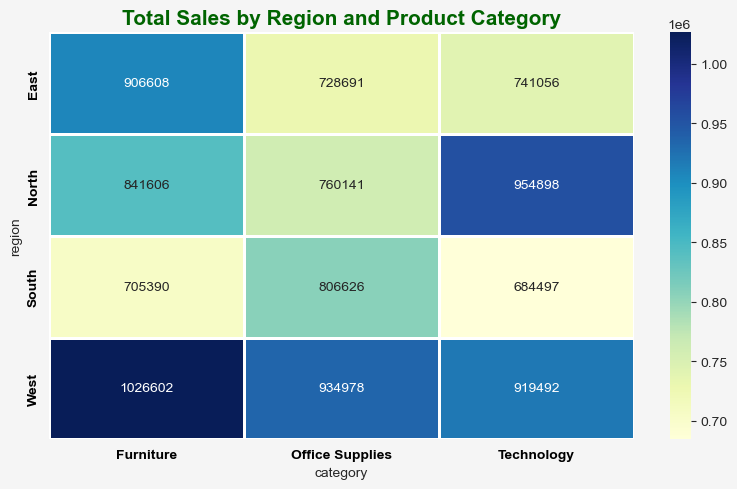

In [64]:


pivot = df.pivot_table(
    values='sales',
    index='region',
    columns='category',
    aggfunc='sum',
    observed=True 
)

plt.figure(figsize=(8,5), facecolor='whitesmoke')

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=1
)

plt.title(
    "Total Sales by Region and Product Category",
    fontsize=15,
    fontweight='bold',
    color='darkgreen'
)

plt.xticks(fontsize=10,color='black',fontweight='bold')
plt.yticks(fontsize=10,color='black',fontweight='bold')

plt.xlabel("Region", fontweight='bold',fontsize=12,color='navy')
plt.ylabel("Number of Orders", fontweight='bold',fontsize=12,color='navy')


plt.tight_layout()

plt.show()